# How the free-final-time DAE optimizer is built, and how we check it

The comparison tutorials answer *what* the optimizers produce. This notebook
answers the two questions underneath that: **how is the Pyomo.DAE model
actually assembled from the same physics the legacy SciPy optimizers use**, and
**what evidence says the assembled model is right**.

It covers all three control modes that `lyopronto.pyomo_models.dae_optimization`
exposes — shelf temperature, chamber pressure, and joint — and it ends with the
verification probes that back the claims: constraint activity read both
geometrically and by marginal value, a mechanism whose conclusion flips when its
precondition stops holding, and the reason reported speedups are not a property
of the methods.

Every number below is computed at run time. Nothing is transcribed by hand.

## Setup

In [1]:
# Papermill parameters. CI overrides these with a smaller, faster case.
a1 = 16.0
kc = 2.75e-4
kc_sweep_values = [2.75e-4, 3.30e-4, 4.00e-4]
point_budget = 49
ncp = 3
final_dried_fraction = 1.0
scipy_dt = 0.01
scipy_dt_sweep = [0.04, 0.02, 0.01, 0.005]
slack_shelf_ceiling_c = 400.0

In [2]:
from importlib.metadata import version
from pathlib import Path
import copy
import subprocess
import sys
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pyomo.environ as pyo

repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from lyopronto import constant, functions
from lyopronto.pyomo_models import (
    create_dae_chamber_pressure_optimization_model,
    create_dae_joint_optimization_model,
    create_dae_shelf_temperature_optimization_model,
    solve_dae_shelf_temperature_optimization,
)
from examples.current_main_comparison import (
    legacy_equality_residuals,
    matched_nfe_for_point_budget,
)
from examples.current_main_optimizer_comparison import (
    comparison_inputs as shelf_inputs,
    run_scipy_reference as run_shelf_scipy,
)
from examples.current_main_pressure_optimizer_comparison import (
    comparison_inputs as pressure_inputs,
)
from examples.current_main_joint_optimizer_comparison import (
    comparison_inputs as joint_inputs,
)

git_revision = subprocess.run(
    ["git", "rev-parse", "HEAD"],
    cwd=repo_root, capture_output=True, text=True, check=False,
).stdout.strip() or "unknown"

# The residuals, duals, and timings below all come out of IPOPT, so record
# which build produced them alongside the Python-package versions.
ipopt = pyo.SolverFactory("ipopt")
ipopt_version = (
    ".".join(str(part) for part in ipopt.version()) if ipopt.available(False) else "unavailable"
)

finite_difference_nfe, collocation_nfe = matched_nfe_for_point_budget(point_budget, ncp)

print(
    f"LyoPRONTO {version('lyopronto')} | SciPy {version('scipy')} | "
    f"Pyomo {version('pyomo')} | IPOPT {ipopt_version} | git_revision {git_revision}"
)
print(
    f"Matched {point_budget}-point budget: finite differences nfe="
    f"{finite_difference_nfe}, collocation nfe={collocation_nfe} with ncp={ncp}"
)

LyoPRONTO 1.1.0 | SciPy 1.17.1 | Pyomo 6.9.5 | IPOPT 3.13.2.0 | git_revision ad6826c2b025b0055e406f3dd94d9cfa795a36ab
Matched 49-point budget: finite differences nfe=48, collocation nfe=16 with ncp=3


# Part 1 — How the model is built

## 1.1 Two ways to pose the same process question

`opt_Tsh.dry` walks the cake forward one step at a time. At each dried-cake
state it solves a small SciPy problem that maximizes the sublimation rate, then
advances the single differential state until the cake is dry. It is a *greedy*
policy: it never reconsiders an earlier choice.

The DAE model poses the whole trajectory at once. Time is normalized to
$\tau \in [0, 1]$, the physical horizon $t_{final}$ becomes a decision variable,
and the objective is simply to minimize it.

Those two are equivalent here, and the reason is worth stating precisely. There
is one monotone differential state, the drying-front position $L_{ck}$, and its
rate depends only on the current state and controls — not on history. Total time
is therefore

$$t_{final} = \int_0^{L_{pr0}} \frac{\mathrm{d}L_{ck}}{\dot L_{ck}(L_{ck}, u)}$$

Maximizing the integrand's denominator pointwise minimizes the integral. That is
exactly what the greedy policy does, so greedy is time-optimal — *provided* the
feasible set at each state does not depend on the path taken to reach it, which
holds because every constraint here is pointwise in time.

## 1.2 The normalized-time model

`ContinuousSet` carries $\tau$, `DerivativeVar` carries $\mathrm{d}L_{ck}/\mathrm{d}\tau$,
and the chain rule puts the free horizon into the dynamics:

$$\frac{\mathrm{d}L_{ck}}{\mathrm{d}\tau} = t_{final}\cdot \dot L_{ck}$$

That single multiplication is what makes the final time free while keeping the
mesh fixed. Here are the pieces on a freshly built model.

In [3]:
shelf_case = shelf_inputs(a1, kc)
demo = create_dae_shelf_temperature_optimization_model(
    shelf_case["vial"], shelf_case["product"], shelf_case["ht"],
    shelf_case["pchamber"], shelf_case["tshelf"],
    eq_cap=shelf_case["eq_cap"], nvial=shelf_case["nvial"],
    nfe=collocation_nfe, discretization="collocation", ncp=ncp,
    final_dried_fraction=final_dried_fraction,
)

print("objective:", demo.obj.expr, "(sense=minimize)")
print("time domain:", f"tau in [{min(demo.t)}, {max(demo.t)}] with {len(demo.t)} points")
print("free horizon:", f"t_final in {demo.t_final.bounds} hr\n")

print("Differential and algebraic structure")
print(f"  {'component':28} {'kind':12} {'indexed by tau':>15}")
for name in ("t_final", "Lck", "dLck_dt", "Tsh", "Pch", "Tsub", "Tbot", "dmdt", "Kv"):
    comp = getattr(demo, name)
    print(f"  {name:28} {type(comp).__name__:12} {str(comp.is_indexed()):>15}")

print("\nConstraints carrying the physics")
for con in demo.component_objects(pyo.Constraint, active=True):
    print(f"  {con.name:34} {len(con):4d} instance(s)")

objective: t_final (sense=minimize)
time domain: tau in [0, 1] with 49 points
free horizon: t_final in (0.1, 50.0) hr

Differential and algebraic structure
  component                    kind          indexed by tau
  t_final                      ScalarVar              False
  Lck                          IndexedVar              True
  dLck_dt                      DerivativeVar            True
  Tsh                          IndexedVar              True
  Pch                          IndexedVar              True
  Tsub                         IndexedVar              True
  Tbot                         IndexedVar              True
  dmdt                         IndexedVar              True
  Kv                           IndexedVar              True

Constraints carrying the physics
  initial_dried_cake                    1 instance(s)
  drying_front_dynamics                49 instance(s)
  final_drying_target                   1 instance(s)
  vapor_pressure_log                   49 insta

## 1.3 Is it the *same* physics? Check against the legacy functions

This is the load-bearing claim, so it gets a direct test rather than a reading
of the source. `functions.Eq_Constraints` returns the four legacy equality
residuals ($C_1$ vapor pressure, $C_2$ sublimation rate, $C_3$ vial heat
balance, $C_4$ shelf temperature) that the SciPy optimizers drive to zero.

We solve the DAE, take its trajectory back out in the legacy seven-column form,
and feed every row through those same legacy functions. If the DAE encodes the
same physics, the legacy residuals must vanish at the DAE's own solution —
without the DAE ever having called them.

The four residuals carry *different units* — Torr, kg/hr, cal cm/s, degC — so
there is no single absolute threshold that is meaningful for all of them. One
loose enough for the degC equation hides a large error in the kg/hr equation,
whose terms are O(1e-3). Each is therefore reported separately, and normalized
by the largest magnitude that equation actually reaches on this trajectory, so
the comparable quantity is a dimensionless relative residual.

In [4]:
solved = solve_dae_shelf_temperature_optimization(
    shelf_case["vial"], shelf_case["product"], shelf_case["ht"],
    shelf_case["pchamber"], shelf_case["tshelf"],
    eq_cap=shelf_case["eq_cap"], nvial=shelf_case["nvial"],
    nfe=collocation_nfe, discretization="collocation", ncp=ncp,
    final_dried_fraction=final_dried_fraction,
)
assert solved.success, solved.message
table = solved.as_table()

identity = legacy_equality_residuals(table, shelf_case)

print(f"DAE optimum: t_final = {solved.objective_time_hr:.6f} hr over {len(table)} points")
print("Legacy residuals evaluated at the DAE solution, per equation:\n")
print(f"  {'equation':20} {'unit':10} {'max |residual|':>15} {'scale':>13} {'relative':>12}")
for name, entry in identity.items():
    print(
        f"  {name:20} {entry['unit']:10} {entry['max_absolute']:15.3e} "
        f"{entry['scale']:13.3e} {entry['max_relative']:12.3e}"
    )
print("\nEach 'scale' is the largest magnitude of that equation's own terms")
print("(" + "; ".join(f"{n}: {e['scale_term']}" for n, e in identity.items()) + ").")

DAE optimum: t_final = 2.125040 hr over 49 points
Legacy residuals evaluated at the DAE solution, per equation:

  equation             unit        max |residual|         scale     relative
  vapor_pressure       Torr             0.000e+00     3.011e+00    0.000e+00
  sublimation_rate     kg/hr            7.156e-18     1.086e-03    6.590e-15
  vial_heat_balance    cal cm/s         1.200e-09     1.415e-01    8.481e-09
  shelf_temperature    degC             1.179e-06     1.344e+02    8.773e-09

Each 'scale' is the largest magnitude of that equation's own terms
(vapor_pressure: sublimation-front pressure; sublimation_rate: sublimation rate; vial_heat_balance: conducted heat through the frozen layer; shelf_temperature: shelf-to-bottom temperature difference).


Every relative residual sits around 1e-9 — solver tolerance, not physics. The
two formulations are the same physics, differently posed.

Reading these per equation is what makes the check meaningful. A single
`max(...)` across all four would be dominated by whichever equation happens to
carry the largest units, and a 10% error in the sublimation-rate equation would
sit at `9.9e-05` — comfortably under a `1e-4` absolute bound while being a gross
physics error. Normalized, that same error reads `9.1e-02`, five orders above
where a converged solve lands. `tests/test_dae_optimizer_walkthrough.py` asserts
the normalized form for exactly this reason.

## 1.4 Three control modes, one model core

All three builders call the same private assembly routine. For the **default,
rate-unlimited cases built below**, they differ only in *which control is free*:
fixing a control is expressed as equal lower and upper bounds rather than as a
structurally different model, which is why the variable and constraint counts
barely move between modes.

That is a statement about these default constructions, not the full public
surface. `create_dae_joint_optimization_model` additionally accepts physical
initial controls (`initial_pressure`, `initial_shelf_temperature`) and
slew-rate limits (`pressure_ramp_rate`, `shelf_temperature_ramp_rate`), which
add real constraints and change the feasible set. The implementability sections
of `current_main_joint_optimizer_comparison.ipynb` exercise those extensions.

In [5]:
mode_builders = {
    "shelf temperature": (create_dae_shelf_temperature_optimization_model, shelf_inputs),
    "chamber pressure": (create_dae_chamber_pressure_optimization_model, pressure_inputs),
    "joint": (create_dae_joint_optimization_model, joint_inputs),
}

def control_is_free(model, name):
    var = getattr(model, name)
    return any(
        var[t].lb is None or var[t].ub is None or var[t].lb != var[t].ub
        for t in model.t
    )

print(f"{'mode':20} {'vars':>6} {'cons':>6} {'points':>7} {'Pch free':>9} {'Tsh free':>9}")
print("-" * 62)
mode_models = {}
for label, (builder, inputs) in mode_builders.items():
    case = inputs(a1, kc)
    model = builder(
        case["vial"], case["product"], case["ht"], case["pchamber"], case["tshelf"],
        eq_cap=case["eq_cap"], nvial=case["nvial"],
        nfe=collocation_nfe, discretization="collocation", ncp=ncp,
        final_dried_fraction=final_dried_fraction,
    )
    mode_models[label] = model
    n_var = sum(1 for _ in model.component_data_objects(pyo.Var, active=True))
    n_con = sum(1 for _ in model.component_data_objects(pyo.Constraint, active=True))
    print(
        f"{label:20} {n_var:6d} {n_con:6d} {len(model.t):7d} "
        f"{str(control_is_free(model, 'Pch')):>9} {str(control_is_free(model, 'Tsh')):>9}"
    )

mode                   vars   cons  points  Pch free  Tsh free
--------------------------------------------------------------


shelf temperature       491    492      49     False      True
chamber pressure        491    492      49      True     False
joint                   491    493      49      True      True


## 1.5 Two transcriptions of the identical DAE

Backward finite differences place `nfe + 1` points; Radau collocation places
`nfe * ncp + 1`. Comparing them at equal `nfe` therefore compares different
problem sizes, which is why `matched_nfe_for_point_budget` exists — it picks the
element counts that give both schemes the *same* point budget so the comparison
is about accuracy per point rather than about mesh size.

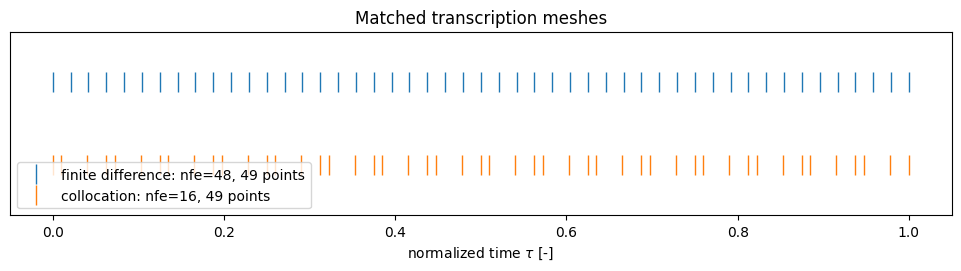

Radau clusters points inside each element and includes the right endpoint,
so it resolves curvature the uniform backward-Euler grid has to average over.


In [6]:
fig, ax = plt.subplots(figsize=(9.5, 2.6), layout="constrained")
for offset, (label, nfe, scheme) in enumerate([
    ("finite difference", finite_difference_nfe, "finite_difference"),
    ("collocation", collocation_nfe, "collocation"),
]):
    mesh = create_dae_shelf_temperature_optimization_model(
        shelf_case["vial"], shelf_case["product"], shelf_case["ht"],
        shelf_case["pchamber"], shelf_case["tshelf"],
        eq_cap=shelf_case["eq_cap"], nvial=shelf_case["nvial"],
        nfe=nfe, discretization=scheme, ncp=ncp,
    )
    tau = sorted(mesh.t)
    ax.plot(tau, np.full(len(tau), -offset), "|", markersize=14,
            label=f"{label}: nfe={nfe}, {len(tau)} points")
ax.set(xlabel=r"normalized time $\tau$ [-]", yticks=[], ylim=(-1.6, 0.6),
       title="Matched transcription meshes")
ax.legend(loc="lower left")
plt.show()

print("Radau clusters points inside each element and includes the right endpoint,")
print("so it resolves curvature the uniform backward-Euler grid has to average over.")

# Part 2 — How we check it

A solve that reports `optimal` has told you almost nothing about whether the
model means what you think. The probes below are the ones that actually moved
our understanding.

## 2.1 Which limit is really binding, and what is it worth?

These are two different questions, and it is worth keeping them apart:

1. **Slack** — evaluate each constraint body at the solution. Slack answers
   whether the constraint is *geometrically active*: positive slack means the
   optimum sits strictly inside it.
2. **Shadow prices** — the solver's multipliers, reported as the change in
   optimal drying time per unit relaxation. These measure *local marginal
   value*.

They are related but not interchangeable. Positive slack does establish
inactivity, and a non-zero multiplier does establish local value. But KKT
complementarity only forces the multiplier to vanish when the constraint is
*in*active — it permits a **zero multiplier on an active constraint** when that
constraint is degenerate or redundant at the optimum. So a zero price means
"no reported marginal value here", not necessarily "inactive".

Both readouts below therefore come from **one** solve whose termination is
checked, rather than from two separate runs. For a nonlinear program two solves
need not land on the same point, so pairing slacks from one with duals from
another would not be two views of a single optimum.

In [7]:
# Both readouts come from `solved` -- the single successful solve above --
# rather than from a second run that need not land on the same point.
capacity_slack = (
    shelf_case["eq_cap"]["a"]
    + shelf_case["eq_cap"]["b"] * solved.values["Pch"]
    - shelf_case["nvial"] * solved.values["dmdt"]
)
temperature_slack = shelf_case["product"]["T_pr_crit"] - solved.values["Tbot"]

print("Geometric activity, from the slack of this same solve:")
print(f"  equipment capability  [kg/hr batch]  min={capacity_slack.min():9.4f}  max={capacity_slack.max():9.4f}")
print(f"  product temperature   [degC]         min={temperature_slack.min():9.2e}  max={temperature_slack.max():9.4f}")
print("  -> positive slack throughout establishes that equipment capability is inactive.")
print("  -> product temperature reaches its bound, so it is active.")

print("\nMarginal value, from the multipliers of that same solve:")
for name, value in sorted(solved.shadow_prices.items()):
    verdict = "no reported marginal value" if abs(value) < 1e-9 else "priced"
    print(f"  {name:34} {value:+12.6f}   {verdict}")
print("\nA zero price alone does not prove inactivity; it is the positive slack")
print("above that rules equipment capability out.")

Geometric activity, from the slack of this same solve:
  equipment capability  [kg/hr batch]  min=   1.1409  max=   1.2863
  product temperature   [degC]         min=-4.84e-08  max=   9.4302
  -> positive slack throughout establishes that equipment capability is inactive.
  -> product temperature reaches its bound, so it is active.

Marginal value, from the multipliers of that same solve:
  equipment_capability                  -0.000000   no reported marginal value
  final_drying_target                   +3.884407   priced
  product_temperature_limit             -0.107483   priced
  shelf_temperature_lower_bound         +0.000000   no reported marginal value
  shelf_temperature_upper_bound         -0.005425   priced

A zero price alone does not prove inactivity; it is the positive slack
above that rules equipment capability out.


Putting the two together: equipment capability is inactive — established by its
**positive slack**, not by its zero price — so buying condenser capacity would
not shorten this cycle. The product-temperature limit is active *and* priced, so
raising the allowed product temperature would.

## 2.2 A mechanism, and the precondition that makes it true

Here is a claim worth being careful about: *drying time does not depend on the
vial heat-transfer coefficient $K_C$.*

The argument. When the product-temperature limit is active, $T_{bot}$ is pinned
at $T_{pr,crit}$. Substituting the energy balance

$$T_{sh} - T_{bot} = \frac{\dot m\, \Delta H_s}{A_v K_v}\cdot\frac{\mathrm{kg\to g}}{\mathrm{hr\to s}}$$

into the frozen-layer heat balance

$$(T_{sh}-T_{bot})\, A_v K_v (L_{pr0}-L_{ck}) = A_p (T_{bot}-T_{sub})\, k_{ice}$$

gives

$$\dot m\,\frac{\mathrm{kg\to g}}{\mathrm{hr\to s}}\,\Delta H_s\,(L_{pr0}-L_{ck}) = A_p (T_{bot}-T_{sub})\, k_{ice}$$

$K_v$ has cancelled. So $\dot m(L_{ck})$, and therefore the drying time, cannot
depend on $K_v$ — and $K_C$ only enters through $K_v$.

But that derivation quietly assumed the shelf can always deliver whatever
temperature the energy balance demands. If the shelf-temperature ceiling binds,
$T_{sh}$ is no longer free to move and the cancellation stops applying. So the
claim is conditional, and the model can tell us which regime we are in.

In [8]:
def sweep_kc(label, adjust):
    rows = []
    for value in kc_sweep_values:
        case = copy.deepcopy(shelf_inputs(a1, value))
        adjust(case)
        result = solve_dae_shelf_temperature_optimization(
            case["vial"], case["product"], case["ht"], case["pchamber"], case["tshelf"],
            eq_cap=case["eq_cap"], nvial=case["nvial"],
            nfe=collocation_nfe, discretization="collocation", ncp=ncp,
            final_dried_fraction=final_dried_fraction,
        )
        assert result.success, result.message
        rows.append({
            "KC": value,
            "t_final": result.objective_time_hr,
            "Tsh_max": result.as_table()[:, 3].max(),
            "shelf_ub_price": result.shadow_prices.get("shelf_temperature_upper_bound", float("nan")),
        })
    print(f"{label}")
    print(f"  {'KC [cal/s/K/cm^2]':>19} {'t_final [hr]':>13} {'max Tsh [degC]':>15} {'shelf-ceiling price':>21}")
    for row in rows:
        print(f"  {row['KC']:19.2e} {row['t_final']:13.6f} {row['Tsh_max']:15.3f} {row['shelf_ub_price']:+21.6f}")
    spread = max(r["t_final"] for r in rows) - min(r["t_final"] for r in rows)
    print(f"  spread in drying time across KC: {spread:.2e} hr\n")
    return rows

shipped = sweep_kc(
    "Shipped paper case: shelf ceiling at "
    f"{shelf_inputs(a1, kc)['tshelf']['max']:.0f} degC",
    lambda case: None,
)
relaxed = sweep_kc(
    f"Same case with the shelf ceiling raised to {slack_shelf_ceiling_c:.0f} degC",
    lambda case: case["tshelf"].update(max=slack_shelf_ceiling_c),
)

Shipped paper case: shelf ceiling at 120 degC
    KC [cal/s/K/cm^2]  t_final [hr]  max Tsh [degC]   shelf-ceiling price
             2.75e-04      2.125040         120.000             -0.005425
             3.30e-04      2.053858         120.000             -0.003501
             4.00e-04      2.010575         120.000             -0.001632
  spread in drying time across KC: 1.14e-01 hr



Same case with the shelf ceiling raised to 400 degC
    KC [cal/s/K/cm^2]  t_final [hr]  max Tsh [degC]   shelf-ceiling price
             2.75e-04      1.983939         209.695             -0.000000
             3.30e-04      1.983940         183.760             -0.000000
             4.00e-04      1.983939         158.607             -0.000000
  spread in drying time across KC: 1.05e-06 hr



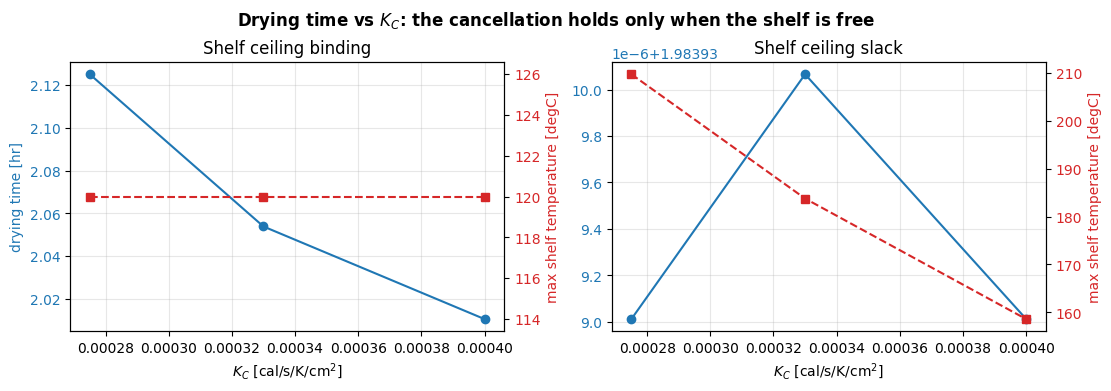

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained", sharex=True)
for ax, rows, title in [
    (axes[0], shipped, "Shelf ceiling binding"),
    (axes[1], relaxed, "Shelf ceiling slack"),
]:
    kcs = [r["KC"] for r in rows]
    ax.plot(kcs, [r["t_final"] for r in rows], "o-", color="tab:blue")
    ax.set(title=title, xlabel=r"$K_C$ [cal/s/K/cm$^2$]")
    ax.grid(alpha=0.3)
    twin = ax.twinx()
    twin.plot(kcs, [r["Tsh_max"] for r in rows], "s--", color="tab:red")
    twin.set_ylabel("max shelf temperature [degC]", color="tab:red")
    twin.tick_params(axis="y", labelcolor="tab:red")
axes[0].set_ylabel("drying time [hr]", color="tab:blue")
for ax in axes:
    ax.tick_params(axis="y", labelcolor="tab:blue")
fig.suptitle(r"Drying time vs $K_C$: the cancellation holds only when the shelf is free",
             fontweight="bold")
plt.show()

Left, the shipped case: the shelf is already pinned at its ceiling, so a better
vial heat-transfer coefficient genuinely does shorten the cycle, and the ceiling
carries a non-zero price. Right, with the ceiling lifted out of the way: drying
time is flat across $K_C$ to six decimals while the shelf temperature the
optimizer asks for falls by tens of degrees, and the ceiling prices at zero.

Same model, same sweep, opposite conclusions — decided entirely by whether one
bound is active. This is the reason to report the precondition alongside the
mechanism rather than the headline alone.

## 2.3 Reported speedups are a property of the comparison, not of the methods

The comparison notebooks report how much faster the simultaneous solve is than
the sequential one. That ratio is real, but it is largely set by a parameter the
tutorial chooses: `opt_Tsh.dry` runs one SciPy solve per `scipy_dt` step, so its
wall time scales as $1/\mathtt{scipy\_dt}$, while the DAE workload is unchanged
by that knob.

In [10]:
dae_start = perf_counter()
dae_reference = solve_dae_shelf_temperature_optimization(
    shelf_case["vial"], shelf_case["product"], shelf_case["ht"],
    shelf_case["pchamber"], shelf_case["tshelf"],
    eq_cap=shelf_case["eq_cap"], nvial=shelf_case["nvial"],
    nfe=collocation_nfe, discretization="collocation", ncp=ncp,
)
dae_wall_s = perf_counter() - dae_start
assert dae_reference.success, dae_reference.message

rows = []
for dt in scipy_dt_sweep:
    run = run_shelf_scipy(a1, kc, dt=dt)
    rows.append({
        "dt": dt, "wall": run.wall_time_s, "objective": run.objective_time_hr,
        "speedup": run.wall_time_s / dae_wall_s,
    })

print(f"DAE collocation solve: {dae_wall_s:.3f} s  (t_final = {dae_reference.objective_time_hr:.4f} hr)\n")
print(f"  {'scipy_dt [hr]':>14} {'SciPy wall [s]':>15} {'t_final [hr]':>13} {'implied speedup':>17}")
for row in rows:
    print(f"  {row['dt']:14.4f} {row['wall']:15.3f} {row['objective']:13.4f} {row['speedup']:16.1f}x")

answer_spread = max(r["objective"] for r in rows) - min(r["objective"] for r in rows)
speedup_ratio = max(r["speedup"] for r in rows) / min(r["speedup"] for r in rows)
print(f"\nAcross this sweep the reported speedup moves by {speedup_ratio:.1f}x,")
print(f"while the SciPy answer itself moves by only {answer_spread:.4f} hr.")

DAE collocation solve: 0.054 s  (t_final = 2.1250 hr)

   scipy_dt [hr]  SciPy wall [s]  t_final [hr]   implied speedup
          0.0400           0.196        2.1168              3.7x
          0.0200           0.387        2.1209              7.2x
          0.0100           0.770        2.1230             14.3x
          0.0050           1.516        2.1240             28.2x

Across this sweep the reported speedup moves by 7.7x,
while the SciPy answer itself moves by only 0.0072 hr.


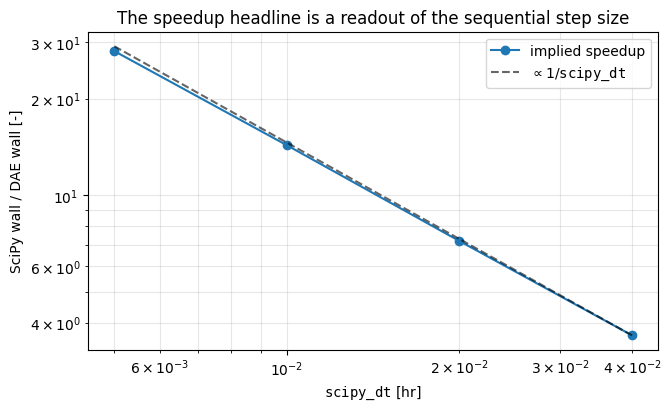

In [11]:
fig, ax = plt.subplots(figsize=(6.6, 4.0), layout="constrained")
dts = [r["dt"] for r in rows]
ax.loglog(dts, [r["speedup"] for r in rows], "o-", label="implied speedup")
reference = rows[0]["speedup"] * (rows[0]["dt"] / np.array(dts))
ax.loglog(dts, reference, "k--", alpha=0.6, label=r"$\propto 1/\mathtt{scipy\_dt}$")
ax.set(xlabel=r"$\mathtt{scipy\_dt}$ [hr]", ylabel="SciPy wall / DAE wall [-]",
       title="The speedup headline is a readout of the sequential step size")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.show()

The measured points track the $1/\mathtt{scipy\_dt}$ reference line. That is why
the tutorials treat objective gaps, not timings, as the portable result: a gap
is a property of the transcription, whereas a speedup is a property of how
finely you chose to run the baseline.

## 2.4 Solver scaling is wired up, and callers can still override it

The DAE model exports a `scaling_factor` suffix. IPOPT ignores that suffix
unless `nlp_scaling_method=user-scaling` is set, so the solve sets it — scoped to
this model, and with `setdefault` so an explicit caller choice wins.

In [12]:
print(f"  {'solver configuration':32} {'t_final [hr]':>14} {'wall [s]':>10}")
for label, override in [
    ("as shipped (user-scaling)", None),
    ("caller override: gradient-based", "gradient-based"),
]:
    configured = pyo.SolverFactory("ipopt")
    if override is not None:
        configured.options["nlp_scaling_method"] = override
    started = perf_counter()
    outcome = solve_dae_shelf_temperature_optimization(
        shelf_case["vial"], shelf_case["product"], shelf_case["ht"],
        shelf_case["pchamber"], shelf_case["tshelf"],
        eq_cap=shelf_case["eq_cap"], nvial=shelf_case["nvial"],
        nfe=collocation_nfe, discretization="collocation", ncp=ncp,
        solver=configured,
    )
    elapsed = perf_counter() - started
    assert outcome.success, outcome.message
    effective = configured.options.get("nlp_scaling_method")
    print(f"  {label:32} {outcome.objective_time_hr:14.9f} {elapsed:10.3f}   -> {effective}")

  solver configuration               t_final [hr]   wall [s]


  as shipped (user-scaling)           2.125040193      0.057   -> user-scaling


  caller override: gradient-based     2.125040214      0.060   -> gradient-based


Both reach the same optimum, and the caller's explicit choice survives — the
model supplies a default, it does not seize the option.

## 2.5 What guards the warmstart unit contract?

`initialize=` accepts a legacy seven-column table and seeds every DAE variable
from it, converting units on the way in: mTorr to Torr, percent dried to cake
length in cm, and sublimation flux to kg/hr per vial. Those conversions are easy
to get wrong and produce plausible-looking numbers when they are.

They are pinned by
`tests/test_pyomo_models/test_dae_optimization.py::test_dae_warmstart_converts_legacy_trajectory_units`,
which builds a hand-written table with distinct values per column and asserts
every seeded quantity — including the free-horizon scaling on the derivative
seed — against independently computed expectations.

That test is deliberately the guard rather than anything in this notebook.
Probing it by mutating the conversions is useful review evidence, but doing it
here would mean matching exact private source strings from
`dae_optimization.py` and importing generated module copies at runtime, which
would make this reader-facing page break on any behavior-preserving refactor of
a private function. The mutation results live in the pull request record
instead.

# Scope and boundaries

- Numbers here are one machine, one solver build, one case. Wall times are
  diagnostics; the objective gaps and the constraint-activity verdicts are the
  portable results.
- The $K_C$ result is deliberately shown in both regimes. Neither is "the"
  answer — which one applies depends on whether the shelf-temperature ceiling
  binds for your case.
- Shadow prices are local sensitivities at the reported optimum and only appear
  for limits whose multipliers the solver exports. A near-zero price means no
  reported marginal value at that point — by complementarity that is consistent
  with an inactive constraint, but also with an active degenerate one, so read
  it together with the slack rather than on its own.
- Section 1.4's "modes differ only by the free control" statement describes the
  default constructions shown here; the joint builder also accepts initial
  controls and slew-rate limits.
- For the process questions themselves — what the optimizers produce, mesh
  sensitivity, implementable cycles — see
  `docs/examples/current_main_joint_optimizer_comparison.ipynb`. This notebook is
  the companion that explains the machinery underneath and the checks on it.